# Imports

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os
from pathlib import Path
import ipaddress
from sklearn.preprocessing import LabelEncoder
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid", palette="muted")

# Helper Functions

In [ ]:
def find_files(directory: str, extension: str) -> list[Path]:
    """
    Recursively find all files with the given extension in a directory.
 
    Args:
        directory: Root directory to search in.
        extension: File extension to filter by (e.g. '.py', 'py', '.txt').
 
    Returns:
        A sorted list of matching Path objects.
    """
    root = Path(directory).resolve()
 
    if not root.exists():
        raise FileNotFoundError(f"Directory not found: {root}")
    if not root.is_dir():
        raise NotADirectoryError(f"Path is not a directory: {root}")
 
    # Normalise extension — ensure it starts with a dot
    ext = extension if extension.startswith(".") else f".{extension}"
 
    return sorted(root.rglob(f"*{ext}"))

In [ ]:
def is_private(ip: str) -> bool:
    try:
        return ipaddress.ip_address(ip).is_private
    except ValueError:
        return False
 
df["DstBytes"]       = df["TotBytes"] - df["SrcBytes"]
df["BytesPerPkt"]    = df["TotBytes"] / df["TotPkts"].replace(0, np.nan)
df["PktsPerSec"]     = df["TotPkts"]  / df["Dur"].replace(0, np.nan)
df["BytesPerSec"]    = df["TotBytes"] / df["Dur"].replace(0, np.nan)
df["SrcPrivate"]     = df["SrcAddr"].apply(is_private)
df["DstPrivate"]     = df["DstAddr"].apply(is_private)
df["Direction"]      = df.apply(
    lambda r: "internal" if r.SrcPrivate and r.DstPrivate
    else ("outbound" if r.SrcPrivate else
          ("inbound"  if r.DstPrivate else "external")), axis=1)
df["IsWellKnownPort"] = df["Dport"] < 1024

# Data Loading

In [ ]:
files = find_files(r'dataset/9','binetflow')

In [ ]:
demo = pd.read_csv(files[0])
display(demo.head(15))

,StartTime,Dur,Proto,SrcAddr,Sport,Dir,DstAddr,Dport,State,sTos,dTos,TotPkts,TotBytes,SrcBytes,Label
0,2011/08/10 09:46:59.607825,1.026539,tcp,94.44.127.113,1577,->,147.32.84.59,6881,S_RA,0.0,0.0,4,276,156,flow=Background-Established-cmpgw-CVUT
1,2011/08/10 09:47:00.634364,1.009595,tcp,94.44.127.113,1577,->,147.32.84.59,6881,S_RA,0.0,0.0,4,276,156,flow=Background-Established-cmpgw-CVUT
2,2011/08/10 09:47:48.185538,3.056586,tcp,147.32.86.89,4768,->,77.75.73.33,80,SR_A,0.0,0.0,3,182,122,flow=Background-TCP-Attempt
3,2011/08/10 09:47:48.230897,3.111769,tcp,147.32.86.89,4788,->,77.75.73.33,80,SR_A,0.0,0.0,3,182,122,flow=Background-TCP-Attempt
4,2011/08/10 09:47:48.963351,3.083411,tcp,147.32.86.89,4850,->,77.75.73.33,80,SR_A,0.0,0.0,3,182,122,flow=Background-TCP-Attempt
5,2011/08/10 09:47:58.806814,3.097288,tcp,147.32.86.89,4866,->,77.75.73.33,80,SR_A,0.0,0.0,3,182,122,flow=Background-TCP-Attempt
6,2011/08/10 09:51:34.450457,1.048908,tcp,213.200.244.217,47908,->,147.32.84.59,6881,S_RA,0.0,0.0,4,244,124,flow=Background-Established-cmpgw-CVUT
7,2011/08/10 09:54:55.231320,4.373526,tcp,75.105.28.60,1419,->,147.32.84.59,6881,S_RA,0.0,0.0,4,252,132,flow=Background-Established-cmpgw-CVUT
8,2011/08/10 09:57:13.352114,4.827912,tcp,75.105.28.60,1491,->,147.32.84.59,6881,S_RA,0.0,0.0,4,252,132,flow=Background-Established-cmpgw-CVUT
9,2011/08/10 09:58:43.301515,0.049697,tcp,178.111.79.115,41752,->,147.32.84.229,13363,SR_SA,0.0,0.0,5,352,208,flow=Background-TCP-Established


In [ ]:
dfs = [pd.read_csv(file).drop(['Dir','StartTime','Label'],axis=1) for file in files]
df = pd.concat(dfs, ignore_index=True)
le = LabelEncoder()
df['Proto'] = le.fit_transform(df['Proto'])
display(df.head())

,Dur,Proto,SrcAddr,Sport,DstAddr,Dport,State,sTos,dTos,TotPkts,TotBytes,SrcBytes
0,1.026539,15,94.44.127.113,1577,147.32.84.59,6881,S_RA,0.0,0.0,4,276,156
1,1.009595,15,94.44.127.113,1577,147.32.84.59,6881,S_RA,0.0,0.0,4,276,156
2,3.056586,15,147.32.86.89,4768,77.75.73.33,80,SR_A,0.0,0.0,3,182,122
3,3.111769,15,147.32.86.89,4788,77.75.73.33,80,SR_A,0.0,0.0,3,182,122
4,3.083411,15,147.32.86.89,4850,77.75.73.33,80,SR_A,0.0,0.0,3,182,122


# EDA

In [38]:
print(f"Shape          : {df.shape}")
print(f"Unique SrcAddr : {df['SrcAddr'].nunique()}")
print(f"Unique DstAddr : {df['DstAddr'].nunique()}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nDtype summary:\n{df.dtypes.value_counts()}")
print(f"\nNumeric summary:")
num_cols = ["Dur", "TotPkts", "TotBytes", "SrcBytes",
            "DstBytes", "BytesPerPkt", "BytesPerSec"]
print(df[num_cols].describe(percentiles=[.25,.5,.75,.90,.99]).round(2).T)

Shape          : (19976700, 19)
Unique SrcAddr : 2031491
Unique DstAddr : 531964

Missing values:
Sport           203085
Dport           194062
State             1378
sTos            220525
dTos           1718011
PktsPerSec      659623
BytesPerSec     659623
dtype: int64

Dtype summary:
float64    6
object     6
int64      4
bool       2
int32      1
Name: count, dtype: int64

Numeric summary:
                  count       mean         std    min     25%        50%  \
Dur          19976700.0     287.95      831.81   0.00    0.00       0.00   
TotPkts      19976700.0      41.39     5545.73   1.00    2.00       2.00   
TotBytes     19976700.0   32327.45  3983037.39  60.00  214.00     264.00   
SrcBytes     19976700.0    6435.36  1667900.75   0.00   78.00      83.00   
DstBytes     19976700.0   25892.08  3505582.42   0.00  120.00     138.00   
BytesPerPkt  19976700.0     180.51      188.90  47.52   82.50     107.00   
BytesPerSec  19317077.0  557482.13  1880693.45   0.03  572.92  296655.8

### Univariate Distribution

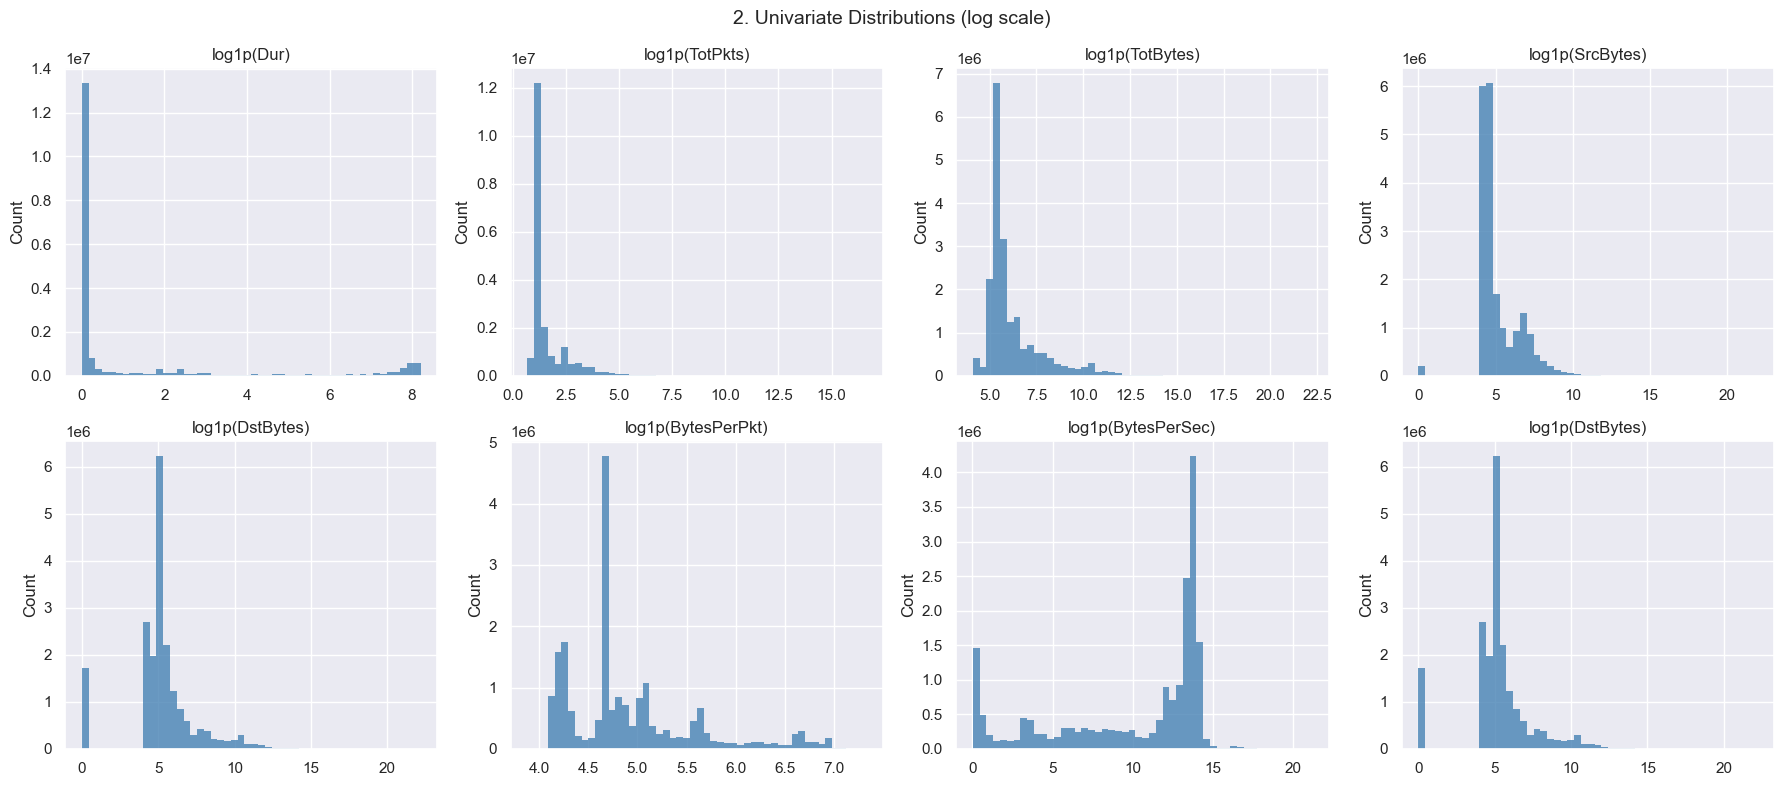

In [39]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("2. Univariate Distributions (log scale)", fontsize=14)
 
for ax, col in zip(axes.flat, num_cols + ["DstBytes"]):
    data = df[col].dropna()
    log_data = np.log1p(data)
    ax.hist(log_data, bins=50, color="steelblue", edgecolor="none", alpha=0.8)
    ax.set_title(f"log1p({col})")
    ax.set_ylabel("Count")
 
plt.tight_layout()
plt.show()

### Protocol

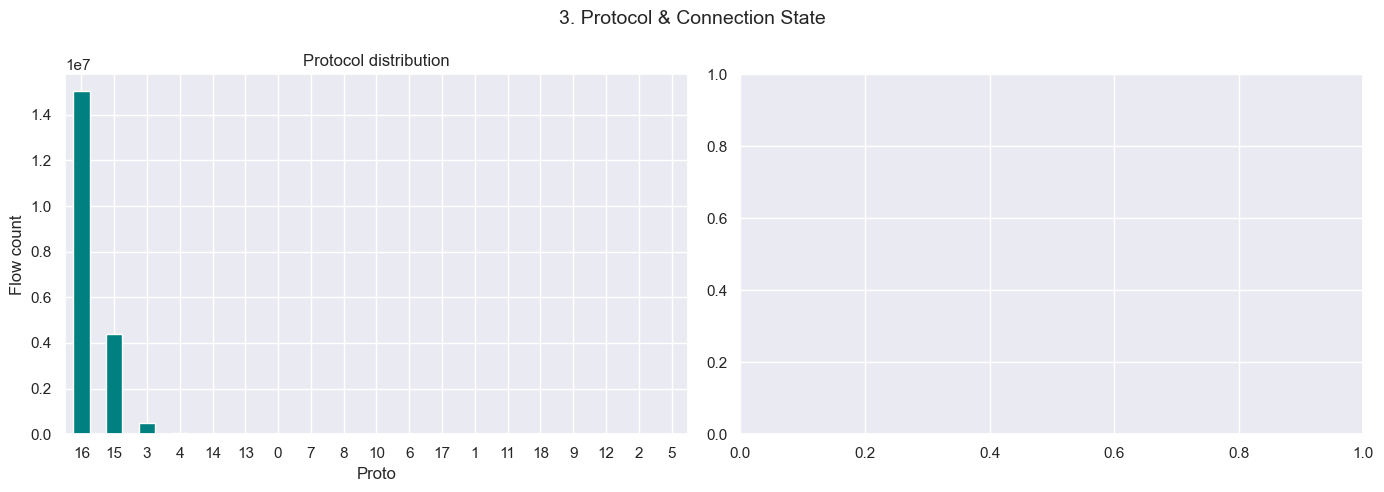

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("3. Protocol & Connection State", fontsize=14)
 
df["Proto"].value_counts().plot.bar(ax=axes[0], color="teal", edgecolor="white")
axes[0].set_title("Protocol distribution")
axes[0].set_xlabel("Proto"); axes[0].set_ylabel("Flow count")
axes[0].tick_params(axis="x", rotation=0)
 
 
plt.tight_layout()
plt.show()

### Top Ports

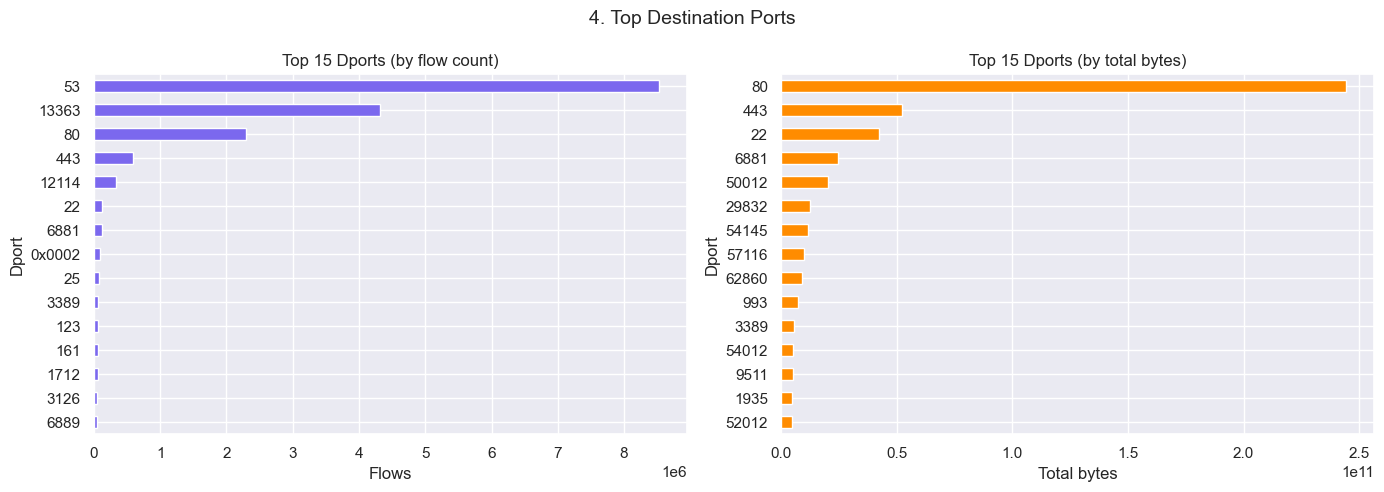

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("4. Top Destination Ports", fontsize=14)
 
top_dport = df["Dport"].value_counts().head(15)
top_dport.plot.barh(ax=axes[0], color="mediumslateblue")
axes[0].set_title("Top 15 Dports (by flow count)")
axes[0].set_xlabel("Flows"); axes[0].invert_yaxis()
 
bytes_by_dport = df.groupby("Dport")["TotBytes"].sum().nlargest(15)
bytes_by_dport.plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title("Top 15 Dports (by total bytes)")
axes[1].set_xlabel("Total bytes"); axes[1].invert_yaxis()
 
plt.tight_layout()
plt.show()

### Top Talkers

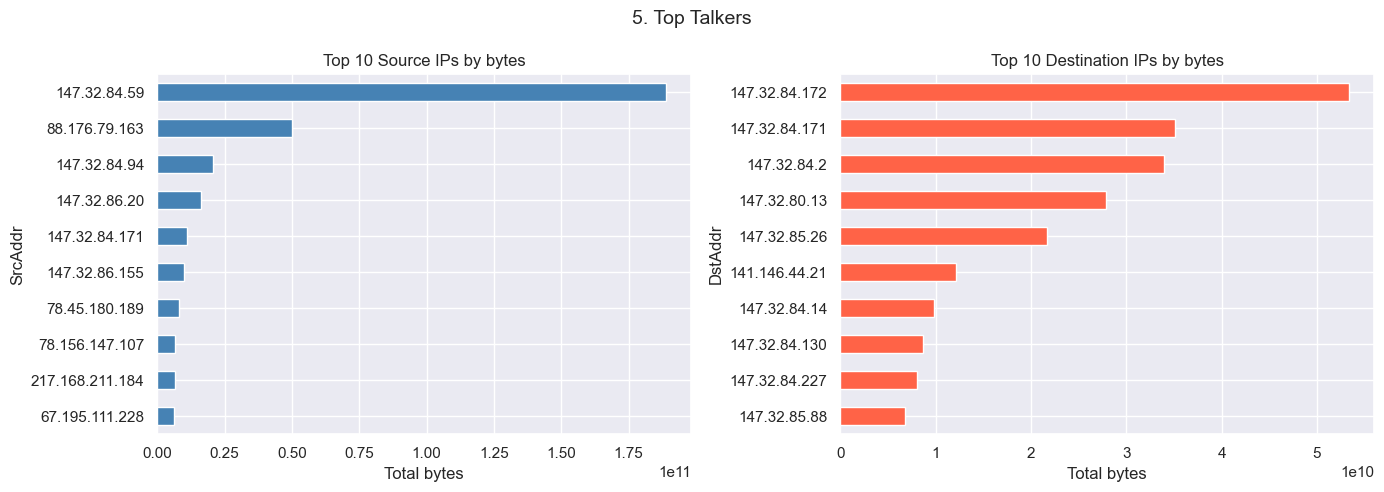

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("5. Top Talkers", fontsize=14)
 
top_src = df.groupby("SrcAddr")["TotBytes"].sum().nlargest(10)
top_src.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 Source IPs by bytes")
axes[0].set_xlabel("Total bytes"); axes[0].invert_yaxis()
 
top_dst = df.groupby("DstAddr")["TotBytes"].sum().nlargest(10)
top_dst.plot.barh(ax=axes[1], color="tomato")
axes[1].set_title("Top 10 Destination IPs by bytes")
axes[1].set_xlabel("Total bytes"); axes[1].invert_yaxis()
 
plt.tight_layout()
plt.show()

### Traffic Direction & Byte Split

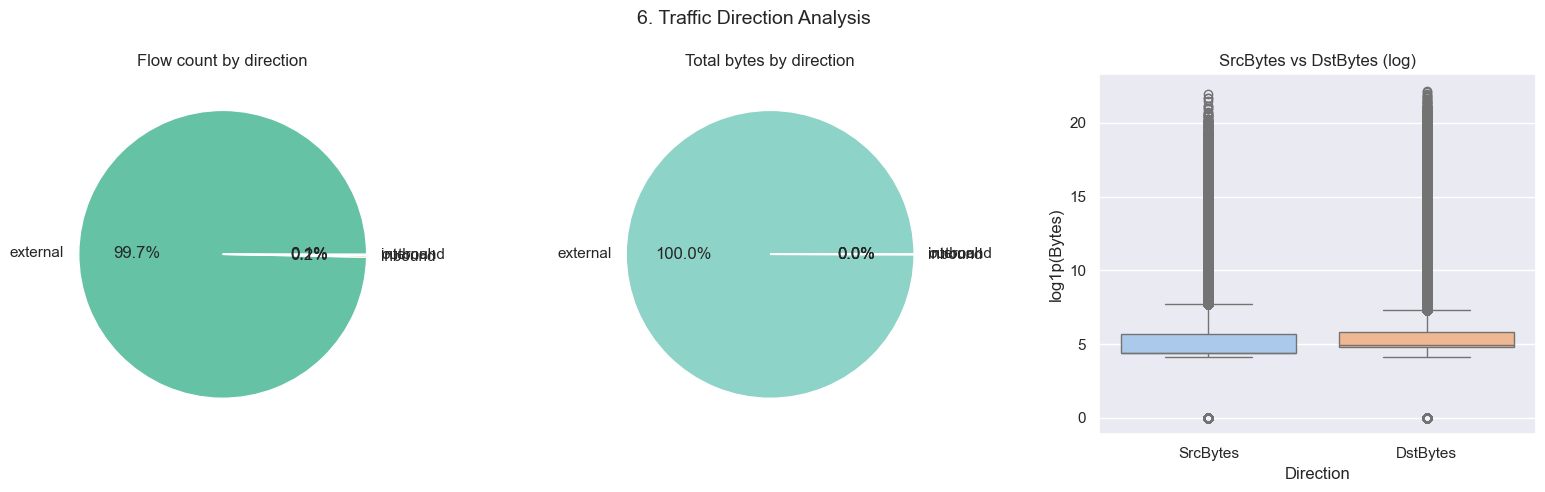

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("6. Traffic Direction Analysis", fontsize=14)
 
dir_counts = df["Direction"].value_counts()
axes[0].pie(dir_counts, labels=dir_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2"))
axes[0].set_title("Flow count by direction")
 
dir_bytes = df.groupby("Direction")["TotBytes"].sum()
axes[1].pie(dir_bytes, labels=dir_bytes.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set3"))
axes[1].set_title("Total bytes by direction")
 
# Src vs Dst bytes box
plot_df = df[["SrcBytes", "DstBytes"]].melt(var_name="Direction", value_name="Bytes")
plot_df["logBytes"] = np.log1p(plot_df["Bytes"])
sns.boxplot(data=plot_df, x="Direction", y="logBytes", ax=axes[2], palette="pastel")
axes[2].set_title("SrcBytes vs DstBytes (log)")
axes[2].set_ylabel("log1p(Bytes)")
 
plt.tight_layout()
plt.show()

### Flow Scatter

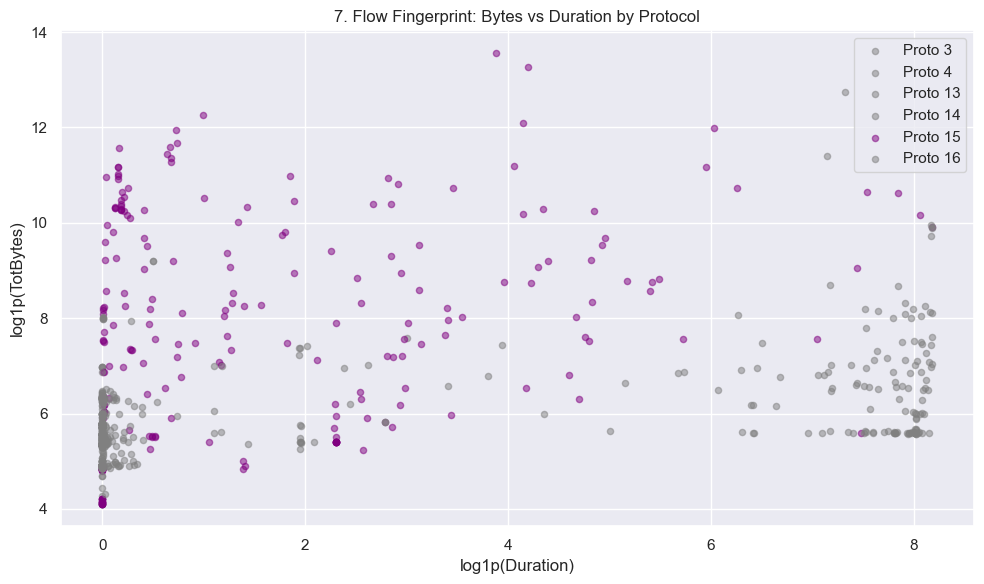

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter_df = df.sample(min(1000, len(df)), random_state=42)
proto_colors = {6: "steelblue", 17: "coral", 1: "green", 15: "purple"}
 
for proto, grp in scatter_df.groupby("Proto"):
    ax.scatter(
        np.log1p(grp["Dur"]), np.log1p(grp["TotBytes"]),
        c=proto_colors.get(proto, "grey"),
        label=f"Proto {proto}", alpha=0.5, s=20,
    )
 
ax.set_xlabel("log1p(Duration)")
ax.set_ylabel("log1p(TotBytes)")
ax.set_title("7. Flow Fingerprint: Bytes vs Duration by Protocol")
ax.legend()
plt.tight_layout()
plt.show()

### Correlation Heatmap

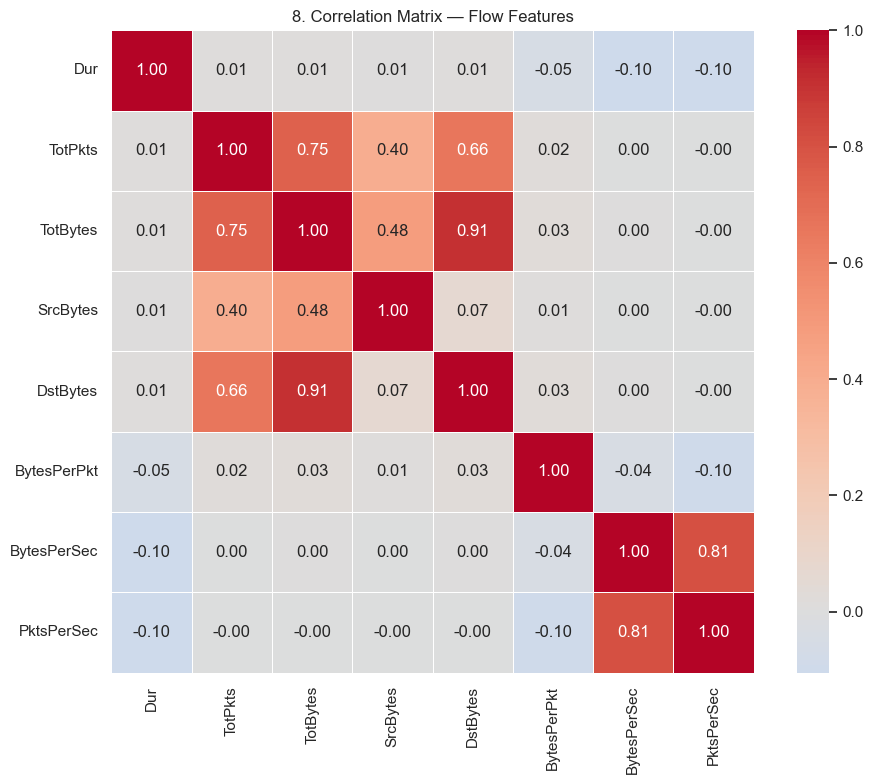

In [47]:
corr_cols = ["Dur", "TotPkts", "TotBytes", "SrcBytes", "DstBytes",
             "BytesPerPkt", "BytesPerSec", "PktsPerSec"]
corr = df[corr_cols].corr()
 
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title("8. Correlation Matrix — Flow Features")
plt.tight_layout()
plt.show()

### Outlier / Elephant Flow Detection

Z-score outliers (|z|>3)   : 1,075,152 flows (5.4%)


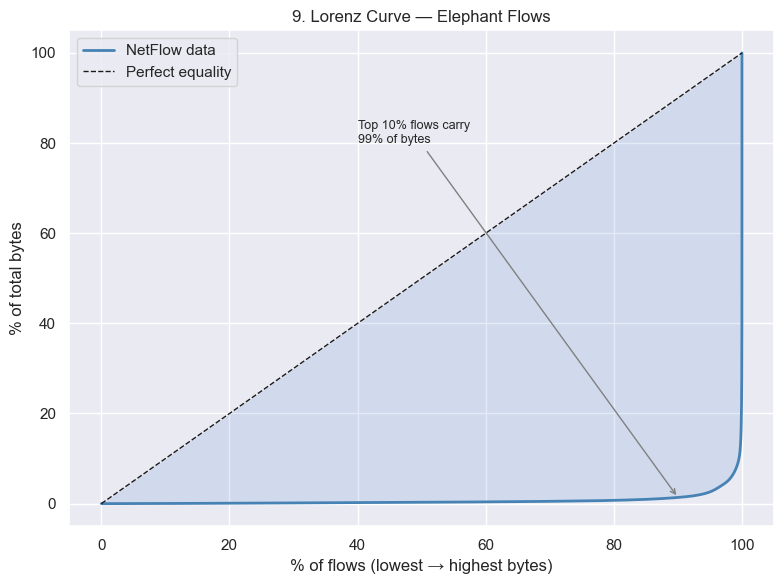

In [50]:
z = np.abs(stats.zscore(df[["TotBytes", "TotPkts", "Dur"]].dropna()))
outliers = df[(z > 3).any(axis=1)]
print(f"Z-score outliers (|z|>3)   : {len(outliers):,} flows "
      f"({100*len(outliers)/len(df):.1f}%)")
 
# Lorenz curve — elephant flows
sorted_bytes = np.sort(df["TotBytes"].values)
cum_bytes = np.cumsum(sorted_bytes) / sorted_bytes.sum()
cum_flows = np.arange(1, len(sorted_bytes) + 1) / len(sorted_bytes)
 
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(cum_flows * 100, cum_bytes * 100, color="steelblue", lw=2, label="NetFlow data")
ax.plot([0, 100], [0, 100], "k--", lw=1, label="Perfect equality")
ax.fill_between(cum_flows * 100, cum_bytes * 100, cum_flows * 100, alpha=0.15)
ax.set_xlabel("% of flows (lowest → highest bytes)")
ax.set_ylabel("% of total bytes")
ax.set_title("9. Lorenz Curve — Elephant Flows")
ax.legend()
 
# Annotate the 90th percentile
idx_90 = int(0.90 * len(cum_flows))
ax.annotate(f"Top 10% flows carry\n{100 - cum_bytes[idx_90]*100:.0f}% of bytes",
            xy=(cum_flows[idx_90]*100, cum_bytes[idx_90]*100),
            xytext=(40, 80), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="grey"))
 
plt.tight_layout()
plt.show()

### Fanout Analysis

Top 10 highest fan-out sources (potential scanners):
               unique_dsts  unique_dports  total_flows   total_bytes
SrcAddr                                                             
147.32.84.229       272747          62436       952954    1650639249
147.32.84.59        109245          53302      1867405  188698499405
147.32.84.118        41040          13237       139894    4123303572
147.32.86.165        40647          28633       106057    1416818537
147.32.84.165        37108            814       180298     636388097
147.32.85.124        28808          13744        57998     678375829
147.32.85.123        14384           9211        33970     338690444
147.32.84.94         10689           9117        79700   20564666299
147.32.86.116         8288           7667         9697      23980812
147.32.86.194         6176           4095        66959    3283449124


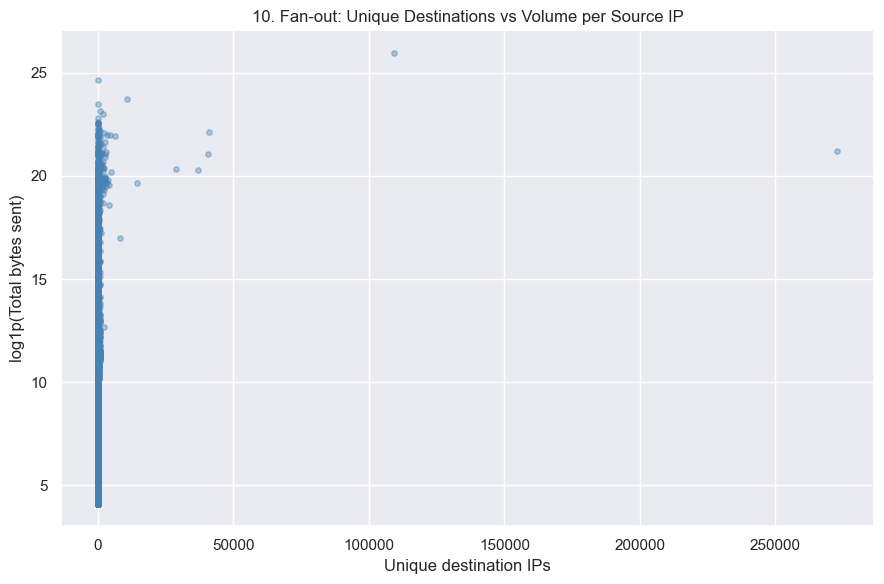

In [51]:
fan_out = (
    df.groupby("SrcAddr")
      .agg(unique_dsts=("DstAddr", "nunique"),
           unique_dports=("Dport", "nunique"),
           total_flows=("TotBytes", "count"),
           total_bytes=("TotBytes", "sum"))
      .sort_values("unique_dsts", ascending=False)
)
 
print("Top 10 highest fan-out sources (potential scanners):")
print(fan_out.head(10).to_string())
 
# Scatter: unique dsts vs total bytes
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(fan_out["unique_dsts"], np.log1p(fan_out["total_bytes"]),
           alpha=0.4, s=15, color="steelblue")
ax.set_xlabel("Unique destination IPs")
ax.set_ylabel("log1p(Total bytes sent)")
ax.set_title("10. Fan-out: Unique Destinations vs Volume per Source IP")
plt.tight_layout()
plt.show()

### TOS Analysis

sTos value counts:
 sTos
0.0      19731588
3.0          8757
192.0        8195
2.0          4553
1.0          3082
Name: count, dtype: int64

dTos value counts:
 dTos
0.0    18255649
3.0        1500
2.0        1400
1.0         140
Name: count, dtype: int64


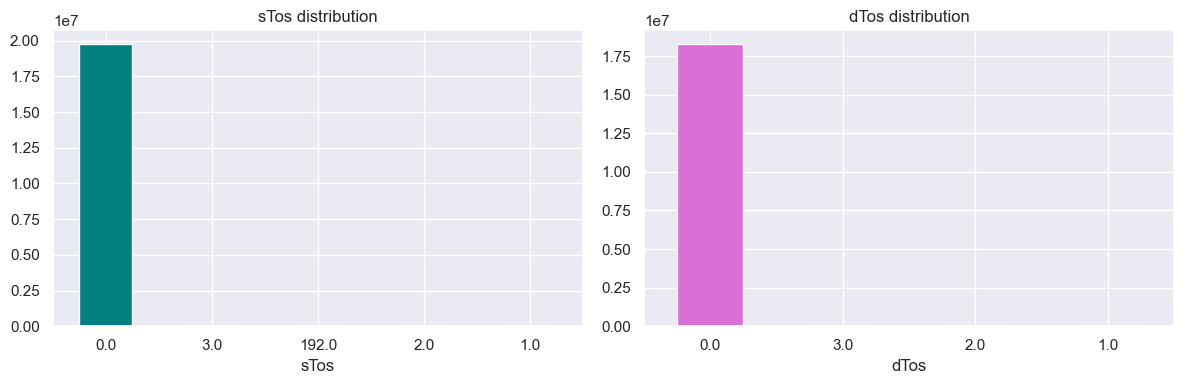

In [52]:
print("sTos value counts:\n", df["sTos"].value_counts())
print("\ndTos value counts:\n", df["dTos"].value_counts())
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["sTos"].value_counts().plot.bar(ax=axes[0], color="teal", title="sTos distribution")
df["dTos"].value_counts().plot.bar(ax=axes[1], color="orchid", title="dTos distribution")
axes[0].tick_params(axis="x", rotation=0)
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()